In [4]:
import numpy as np
import matplotlib.pyplot as plt
from torchvision.datasets import EMNIST
from torchvision import transforms
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split


In [5]:
# Load and preprocess EMNIST
transform = transforms.Compose([transforms.ToTensor()])
train_data = EMNIST(root='./data', split='balanced', train=True, download=True, transform=transform)
test_data = EMNIST(root='./data', split='balanced', train=False, download=True, transform=transform)

# Convert to NumPy and flatten
# EMNIST data is (num_samples, 28, 28)
X_train = train_data.data.numpy().reshape(-1, 28*28)
y_train = train_data.targets.numpy()
X_test = test_data.data.numpy().reshape(-1, 28*28)
y_test = test_data.targets.numpy()

# Split train into train and validation
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.15)


In [6]:
# evaluate function from lek17_trees.ipynb
def evaluate(H, Y, beta=1.0):
   tp = sum((Y == H) * (Y == 1) * 1)
   tn = sum((Y == H) * (Y == 0) * 1)
   fp = sum((Y != H) * (Y == 0) * 1)
   fn = sum((Y != H) * (Y == 1) * 1)

   accuracy = (tp + tn) / (tp + fp + fn + tn)
   sensitivity = tp / (tp + fn)
   specificity = tn / (fp + tn)
   precision = tp / (tp + fp)
   recall = sensitivity
   f_score = ( (beta**2 + 1) * precision * recall) / (beta**2 * precision + recall)
   auc = (sensitivity + specificity) / 2
   youden = sensitivity - (1 - specificity)
   p_plus = sensitivity / (1 - specificity)
   p_minus = (1 - sensitivity) / specificity
   dp = (np.sqrt(3) / np.pi) * (np.log(sensitivity/(1 - sensitivity) + np.log(specificity/(1 - specificity))))

   result = {}
   result["tp"] = tp
   result["tn"] = tn
   result["fp"] = fp
   result["fn"] = fn
   result["accuracy"] = accuracy
   result["sensitivity"] = sensitivity
   result["specificity"] = specificity
   result["precision"] = precision
   result["recall"] = recall
   result["f-score"] = f_score
   result["AUC"] = auc
   result["Youden"] = youden
   result["p+"] = p_plus
   result["p-"] = p_minus
   result["DP"] = dp

   return result


In [7]:
# Random Forest Model
# n_estimators is the number of trees in the forest.
# n_jobs=-1 allows using all processors for training.
# max_depth=10 to keep it manageable and visualizable.
models = [('Random Forest', RandomForestClassifier(n_estimators=100, max_depth=10, n_jobs=-1)),
          ]


In [8]:
for name, model in models:
    print(f'** {name}')
    model.fit(X_train, y_train)
    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)
    # The evaluation function is designed for binary classification (Y==1, Y==0)
    # Since EMNIST is multi-class, standard accuracy is more informative here.
    print(f"Train Accuracy: {model.score(X_train, y_train)}")
    print(f"Val Accuracy: {model.score(X_val, y_val)}")


** Random Forest
Train Accuracy: 0.7691176470588236
Val Accuracy: 0.723758865248227


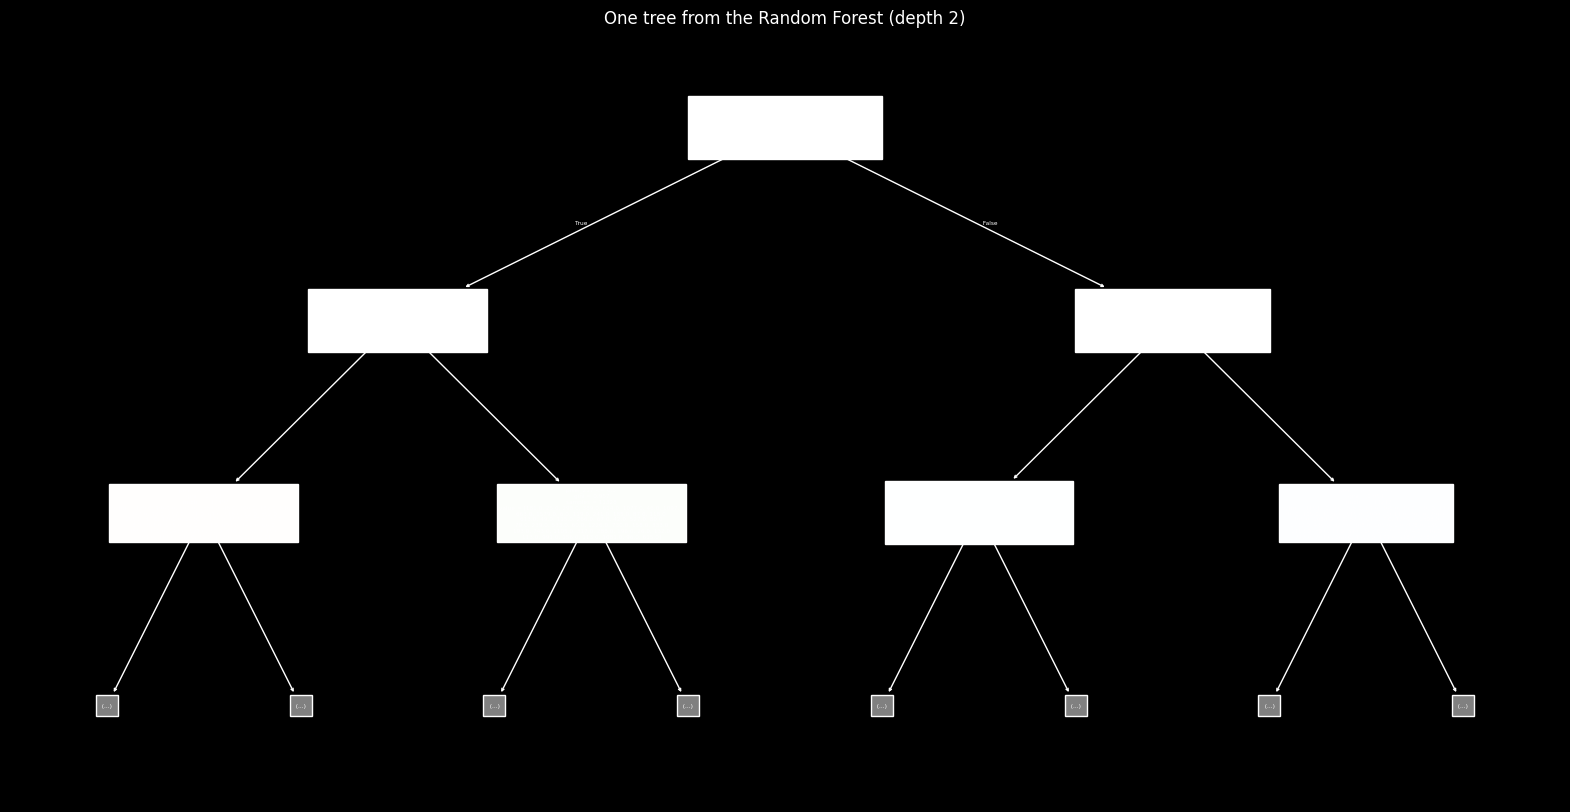

In [9]:
# Plot one of the trees from the forest (e.g., the first estimator)
plt.figure(figsize=(20,10))
plot_tree(models[0][1].estimators_[0], max_depth=2, feature_names=[f"pixel_{i}" for i in range(784)], filled=True)
plt.title("One tree from the Random Forest (depth 2)")
plt.show()
